In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern, hog

from sklearn.model_selection import (
    train_test_split,
    learning_curve
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# =====================================================
# CHANGE THESE ONLY DURING EXAM
# =====================================================

DATASET_PATH = "dataset"

CLASS_MAP = {
    "fresh": 0,
    "rotten": 1
}

IMAGE_SIZE = (128, 128)

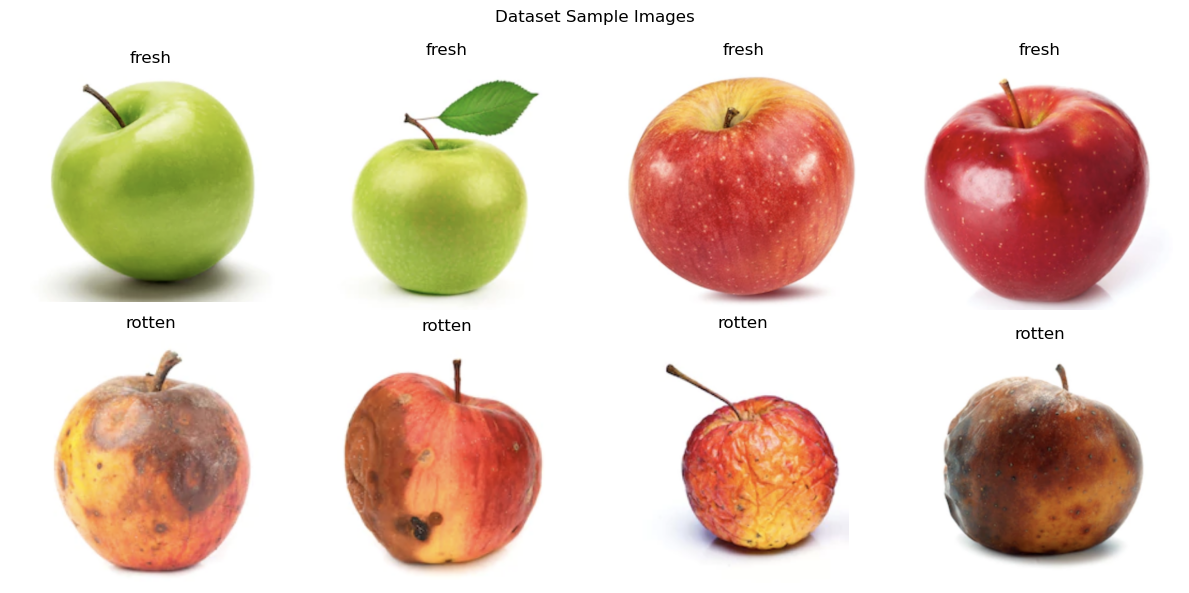

In [3]:
def show_sample_images(base_path, class_map, samples=4):

    classes = list(class_map.keys())

    fig, axes = plt.subplots(
        len(classes),
        samples,
        figsize=(samples * 3, len(classes) * 3)
    )

    for r, cls in enumerate(classes):

        folder = os.path.join(base_path, cls)

        image_files = [
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ][:samples]

        for c, file in enumerate(image_files):

            path = os.path.join(folder, file)

            img = cv2.imread(path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = axes[r][c] if len(classes) > 1 else axes[c]

            ax.imshow(img)
            ax.set_title(cls)
            ax.axis("off")

    plt.suptitle("Dataset Sample Images")
    plt.tight_layout()
    plt.show()


show_sample_images(DATASET_PATH, CLASS_MAP)

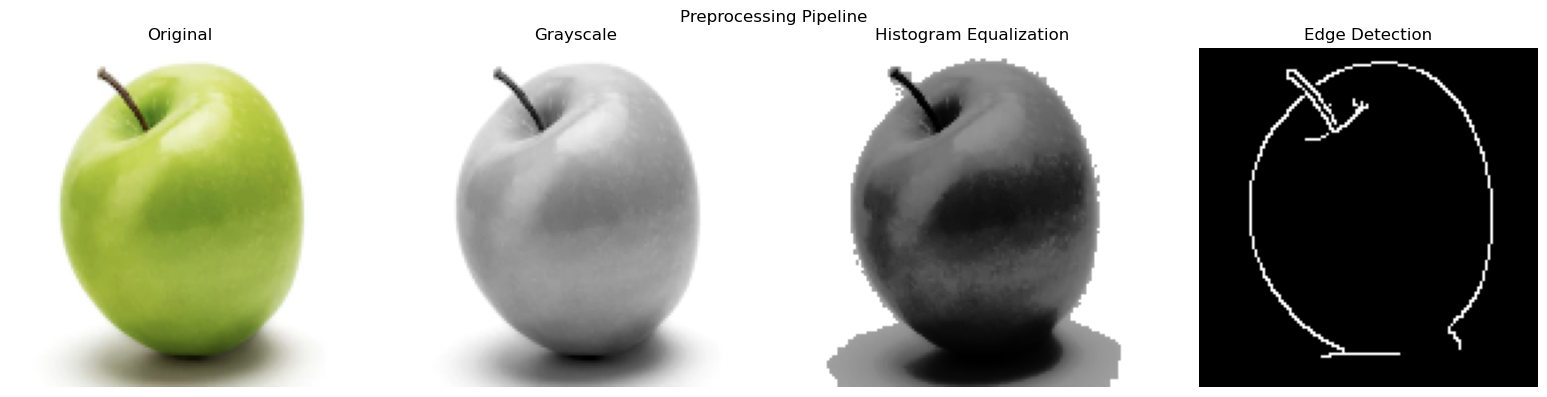

In [4]:
def show_preprocessing_demo(image_path):

    image = cv2.imread(image_path)

    if image is None:
        print("Cannot read image")
        return

    image = cv2.resize(image, IMAGE_SIZE)

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    equalized = cv2.equalizeHist(gray)

    edges = cv2.Canny(gray, 100, 200)

    fig, axes = plt.subplots(1,4, figsize=(16,4))

    axes[0].imshow(rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(gray, cmap='gray')
    axes[1].set_title("Grayscale")
    axes[1].axis("off")

    axes[2].imshow(equalized, cmap='gray')
    axes[2].set_title("Histogram Equalization")
    axes[2].axis("off")

    axes[3].imshow(edges, cmap='gray')
    axes[3].set_title("Edge Detection")
    axes[3].axis("off")

    plt.suptitle("Preprocessing Pipeline")
    plt.tight_layout()
    plt.show()


sample_class = list(CLASS_MAP.keys())[0]

sample_folder = os.path.join(DATASET_PATH, sample_class)

sample_image = os.listdir(sample_folder)[0]

sample_path = os.path.join(sample_folder, sample_image)

show_preprocessing_demo(sample_path)

show_contours() defined


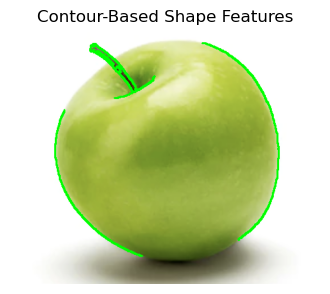

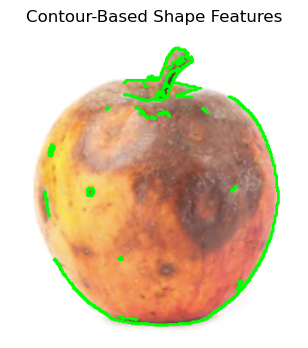

In [5]:
def show_contours(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Cannot read: {img_path}"); return
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    contour_img = img.copy()
    cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    plt.title("Contour-Based Shape Features")
    plt.axis("off")
    plt.show()

print("show_contours() defined")

# ── UPDATE THESE PATHS ON EXAM DAY ──────────────────────
sample_img_class_a = "dataset/fresh/Screen Shot 2018-06-08 at 4.59.44 PM.png"   # ← any image from class_a
sample_img_class_b = "dataset/rotten/Screen Shot 2018-06-07 at 2.15.34 PM.png"   # ← any image from class_b
# ─────────────────────────────────────────────────────────

show_contours(sample_img_class_a)
show_contours(sample_img_class_b)

In [6]:
def load_dataset(base_path, class_map):

    images = []
    labels = []

    for class_name, label in class_map.items():

        folder_path = os.path.join(base_path, class_name)

        if not os.path.exists(folder_path):
            print(f"Folder not found: {folder_path}")
            continue

        for image_name in os.listdir(folder_path):

            image_path = os.path.join(folder_path, image_name)

            try:

                image = cv2.imread(image_path)

                # corrupted image handling
                if image is None:
                    print(f"Corrupted image skipped: {image_name}")
                    continue

                image = cv2.resize(image, IMAGE_SIZE)

                images.append(image)

                labels.append(label)

            except:
                print(f"Error loading: {image_name}")
                continue

    return np.array(images), np.array(labels)


images, labels = load_dataset(
    DATASET_PATH,
    CLASS_MAP
)

print("Dataset Loaded Successfully")

print("Images Shape:", images.shape)

print("Labels Shape:", labels.shape)

Dataset Loaded Successfully
Images Shape: (60, 128, 128, 3)
Labels Shape: (60,)


In [7]:
def extract_features(image):

    features = []

    # =====================================================
    # A. COLOR FEATURES (HSV HISTOGRAM)
    # =====================================================

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    hist = cv2.calcHist(
        [hsv],
        [0,1,2],
        None,
        [8,8,8],
        [0,256,0,256,0,256]
    )

    hist = cv2.normalize(hist, hist).flatten()

    features.extend(hist)


    # =====================================================
    # B. TEXTURE FEATURES (LBP)
    # =====================================================

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    lbp = local_binary_pattern(
        gray,
        P=8,
        R=1,
        method='uniform'
    )

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0,11),
        range=(0,10)
    )

    lbp_hist = lbp_hist.astype("float")

    lbp_hist /= (lbp_hist.sum() + 1e-6)

    features.extend(lbp_hist)


    # =====================================================
    # C. HOG FEATURES
    # =====================================================

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        feature_vector=True
    )

    features.extend(hog_features[:300])


    # =====================================================
    # D. SHAPE FEATURES USING CONTOURS
    # =====================================================

    _, thresh = cv2.threshold(
        gray,
        127,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) > 0:

        cnt = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(cnt)

        perimeter = cv2.arcLength(cnt, True)

        circularity = 0

        if perimeter != 0:

            circularity = (
                4 * np.pi * area
            ) / (perimeter ** 2)

        features.extend([
            area,
            perimeter,
            circularity
        ])

    else:

        features.extend([0,0,0])

    return np.array(features)

In [8]:
feature_vectors = []

for img in images:

    fv = extract_features(img)

    feature_vectors.append(fv)

X = np.array(feature_vectors)

y = labels

print("Feature Extraction Completed")

print("Feature Matrix Shape:", X.shape)

Feature Extraction Completed
Feature Matrix Shape: (60, 825)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))

print("Testing Samples:", len(X_test))

Training Samples: 48
Testing Samples: 12


In [10]:
models = {

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        kernel='rbf'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [11]:
results = {}

trained_models = {}

predictions = {}

for model_name, model in models.items():

    print("\n===================================")

    print(f"Training Model: {model_name}")

    print("===================================")

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[model_name] = accuracy

    trained_models[model_name] = pipeline

    predictions[model_name] = y_pred

    print(f"Accuracy: {accuracy:.4f}")


Training Model: KNN


/lib/python3.13/site-packages/threadpoolctl.py:1123: RuntimeWarning: JsProxy.as_object_map() is deprecated. Use as_py_json() instead.
  for filepath in LDSO.loadedLibsByName.as_object_map():


Accuracy: 0.5000

Training Model: SVM
Accuracy: 0.5833

Training Model: Random Forest
Accuracy: 0.8333


In [12]:
best_model_name = max(
    results,
    key=results.get
)

best_model = trained_models[best_model_name]

best_predictions = predictions[best_model_name]

print("\n===================================")

print("FINAL MODEL COMPARISON")

print("===================================")

for model_name, accuracy in results.items():

    print(f"{model_name}: {accuracy:.4f}")

print(f"\nBest Performing Model: {best_model_name}")


FINAL MODEL COMPARISON
KNN: 0.5000
SVM: 0.5833
Random Forest: 0.8333

Best Performing Model: Random Forest


In [13]:
print("\n===================================")

print("BEST MODEL CLASSIFICATION REPORT")

print("===================================")

print(
    classification_report(
        y_test,
        best_predictions
    )
)


BEST MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



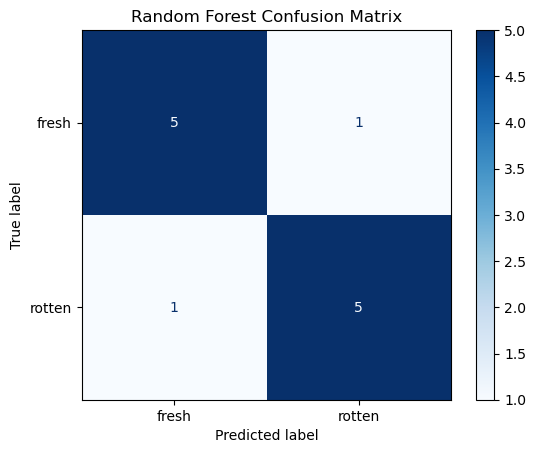

In [14]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(CLASS_MAP.keys())
)

disp.plot(cmap='Blues')

plt.title(
    f"{best_model_name} Confusion Matrix"
)

plt.show()

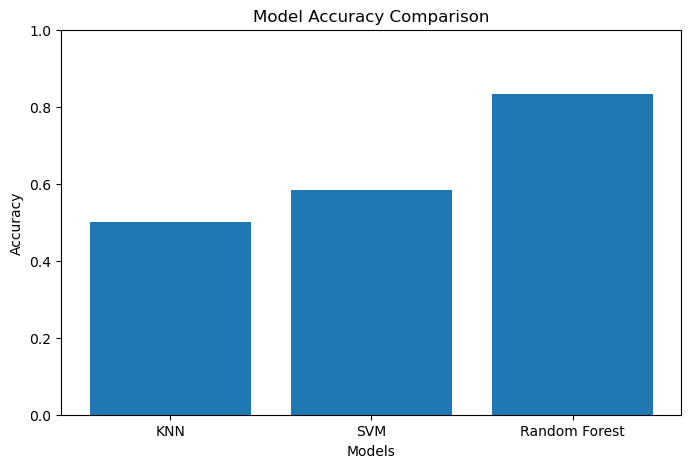

In [15]:
model_names = list(results.keys())

accuracies = list(results.values())

plt.figure(figsize=(8,5))

plt.bar(model_names, accuracies)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.ylim(0,1)

plt.show()

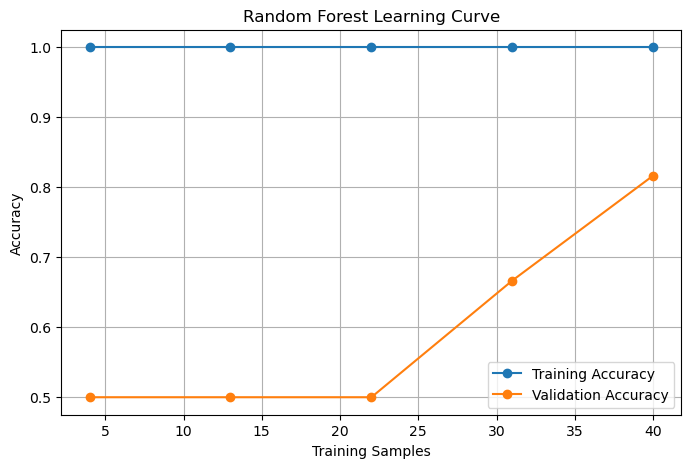

In [16]:
train_sizes, train_scores, test_scores = learning_curve(

    best_model,

    X,

    y,

    cv=3,

    scoring='accuracy',

    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    test_mean,
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title(
    f"{best_model_name} Learning Curve"
)

plt.legend()

plt.grid()

plt.show()